In [1]:
# Importing Important Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [5]:
import os
os.chdir(r"C:\Users\Harshit\Downloads\Machine Learning\Projects LearnBay\HealthCare Domain")

In [7]:
# Reading the File
df = pd.read_csv(r"kidney_disease.csv")
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


# About the Dataset:
The Chronic Kidney Disease (CKD) dataset from the UCI Machine Learning Repository is designed for the classification task of predicting whether a patient has CKD based on various clinical and demographic attributes. The dataset comprises 400 instances, each representing a patient, with 24 features and a target variable indicating the presence (ckd) or absence (notckd) of the disease.

# Problem Statement:
Develop a predictive model that accurately classifies patients as having CKD or not, using the provided clinical and demographic features.

# Dataset Overview:
- Instances: 400 patient records

- Features: 24 attributes, including:

- Numerical: age, blood pressure, blood glucose levels, blood urea, serum creatinine, sodium, potassium, hemoglobin, packed cell volume, white blood cell count, red blood cell count

- Categorical: specific gravity, albumin, sugar, red blood cells, pus cell, pus cell clumps, bacteria, hypertension, diabetes mellitus, coronary artery disease, appetite, pedal edema, anemia

- Target Variable: class — indicates CKD status (ckd or notckd)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

### Checking for Null Values

In [8]:
df.isna().sum().sum()

1009

In [9]:
# Yes we have null values so we will treat them later

In [10]:
# find any duplicate values
df.duplicated().sum()

0

In [11]:
# No Duplicates

## Handling Missing values

In [12]:
df.isna().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [ ]:
# Here we have Null values in every single column so we will go by Simple imputer method to fill all null values at once.

In [13]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan,strategy="most_frequent") #most_frequent = mode
df_imputed = pd.DataFrame(imputer.fit_transform(df))
df_imputed.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0,48.0,80.0,1.02,1.0,0.0,normal,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,normal,normal,notpresent,notpresent,...,38,6000,5.2,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.01,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [14]:
df_imputed.columns = df.columns
df_imputed.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.02,1.0,0.0,normal,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,normal,normal,notpresent,notpresent,...,38,6000,5.2,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.01,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [15]:
df_imputed.isna().sum().sum()

0

In [16]:
# By using this method we can impute all the nan values in one step by filling with mod values

In [17]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              400 non-null    object
 1   age             400 non-null    object
 2   bp              400 non-null    object
 3   sg              400 non-null    object
 4   al              400 non-null    object
 5   su              400 non-null    object
 6   rbc             400 non-null    object
 7   pc              400 non-null    object
 8   pcc             400 non-null    object
 9   ba              400 non-null    object
 10  bgr             400 non-null    object
 11  bu              400 non-null    object
 12  sc              400 non-null    object
 13  sod             400 non-null    object
 14  pot             400 non-null    object
 15  hemo            400 non-null    object
 16  pcv             400 non-null    object
 17  wc              400 non-null    object
 18  rc        

### By imputing all of these columns by using SimpleImputer we have converted num cols to objects, we have to fix that also

### Converting data types as they were initially

In [20]:
for i in df.select_dtypes(exclude = ["object"]).columns:
    df_imputed[i] = df_imputed[i].apply(lambda x: float(x))

In [21]:
df_imputed.dtypes

id                float64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [22]:
# We can see that some of columns that were numerical initially haven't benn converted to float yet, let's check and fix that.

In [24]:
## Checking for Unique values in every feature

In [25]:
for i in df_imputed.columns:
    print("**************************************",i,"********************************************")
    print()
    print(set(df_imputed[i].tolist())) # by using set we are printing unique values
    print()

************************************** id ********************************************

{0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 122.0, 123.0, 124.0, 125.0, 126.0, 127.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0, 137.0, 138.0, 139.0, 140.0, 141.0, 142.0, 143.0, 144.0, 145.0,

In [26]:
## As we can see in some features '\t' is present so let's clean that also.

## Cleaning

In [27]:
#we will go from last to first
df_imputed["classification"].value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

In [28]:
df_imputed["classification"] = df_imputed["classification"].apply(lambda x:"ckd" if x=="ckd\t" else x)

In [29]:
df_imputed["classification"].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [30]:
# now we have problem in cad
df_imputed["cad"].value_counts()

cad
no      364
yes      34
\tno      2
Name: count, dtype: int64

In [31]:
df_imputed["cad"] = df_imputed["cad"].apply(lambda x:"no" if x=="\tno" else x)

In [32]:
df_imputed["cad"].value_counts() #done

cad
no     366
yes     34
Name: count, dtype: int64

In [59]:
# now ther's problem in dm
df_imputed["dm"].value_counts()

dm
no       260
yes      134
\tno       3
\tyes      2
 yes       1
Name: count, dtype: int64

In [33]:
df_imputed["dm"] = df_imputed["dm"].apply(lambda x:"no" if x=="\tno" else ('yes' if x=='\tyes' else x))

In [34]:
df_imputed["dm"].value_counts()

dm
no      263
yes     136
 yes      1
Name: count, dtype: int64

In [35]:
df_imputed["dm"] = df_imputed["dm"].str.strip(" ")

In [36]:
df_imputed["dm"].value_counts()

dm
no     263
yes    137
Name: count, dtype: int64

In [37]:
# now there's problem in rc
df_imputed["rc"].unique()

array(['5.2', '3.9', '4.6', '4.4', '5', '4.0', '3.7', '3.8', '3.4', '2.6',
       '2.8', '4.3', '3.2', '3.6', '4', '4.1', '4.9', '2.5', '4.2', '4.5',
       '3.1', '4.7', '3.5', '6.0', '5.0', '2.1', '5.6', '2.3', '2.9',
       '2.7', '8.0', '3.3', '3.0', '3', '2.4', '4.8', '\t?', '5.4', '6.1',
       '6.2', '6.3', '5.1', '5.8', '5.5', '5.3', '6.4', '5.7', '5.9',
       '6.5'], dtype=object)

In [38]:
# "\t?" this is the problem so for that we will take it's mode and replace it by that
df_imputed["rc"].mode()

0    5.2
Name: rc, dtype: object

In [39]:
df_imputed["rc"] = df_imputed["rc"].apply(lambda x:"5.2" if x=="\t?" else x)

In [40]:
df_imputed["rc"].unique()

array(['5.2', '3.9', '4.6', '4.4', '5', '4.0', '3.7', '3.8', '3.4', '2.6',
       '2.8', '4.3', '3.2', '3.6', '4', '4.1', '4.9', '2.5', '4.2', '4.5',
       '3.1', '4.7', '3.5', '6.0', '5.0', '2.1', '5.6', '2.3', '2.9',
       '2.7', '8.0', '3.3', '3.0', '3', '2.4', '4.8', '5.4', '6.1', '6.2',
       '6.3', '5.1', '5.8', '5.5', '5.3', '6.4', '5.7', '5.9', '6.5'],
      dtype=object)

In [41]:
# now ther's problem in wc
df_imputed["wc"].unique()

array(['7800', '6000', '7500', '6700', '7300', '9800', '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9100', '7900', '6400', '8600',
       '18900', '21600', '4300', '8500', '11300', '7200', '7700', '14600',
       '6300', '\t6200', '7100', '11800', '9400', '5500', '5800', '13200',
       '12500', '5600', '7000', '11900', '10400', '10700', '12700',
       '6800', '6500', '13600', '10200', '9000', '14900', '8200', '15200',
       '5000', '16300', '12400', '\t8400', '10500', '4200', '4700',
       '10900', '8100', '9500', '2200', '12800', '11200', '19100', '\t?',
       '12300', '16700', '2600', '26400', '8800', '7400', '4900', '8000',
       '12000', '15700', '4100', '5700', '11500', '5400', '10800', '9900',
       '5200', '5900', '9300', '9700', '5100', '6600'], dtype=object)

In [42]:
df_imputed["wc"] = df_imputed["wc"].str.replace("\t","")

In [43]:
df_imputed["wc"].mode()

0    9800
Name: wc, dtype: object

In [44]:
df_imputed["wc"] = df_imputed["wc"].apply(lambda x:"9800" if x=="?" else x)

In [45]:
df_imputed["wc"].unique() #done

array(['7800', '6000', '7500', '6700', '7300', '9800', '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9100', '7900', '6400', '8600',
       '18900', '21600', '4300', '8500', '11300', '7200', '7700', '14600',
       '6300', '7100', '11800', '9400', '5500', '5800', '13200', '12500',
       '5600', '7000', '11900', '10400', '10700', '12700', '6800', '6500',
       '13600', '10200', '9000', '14900', '8200', '15200', '5000',
       '16300', '12400', '10500', '4200', '4700', '10900', '8100', '9500',
       '2200', '12800', '11200', '19100', '12300', '16700', '2600',
       '26400', '8800', '7400', '4900', '8000', '12000', '15700', '4100',
       '5700', '11500', '5400', '10800', '9900', '5200', '5900', '9300',
       '9700', '5100', '6600'], dtype=object)

In [46]:
# now there's problem im pcv
df_imputed["pcv"].unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', '41',
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '\t?', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '26', '15',
       '21', '43', '20', '\t43', '47', '9', '49', '50', '53', '51', '54'],
      dtype=object)

In [47]:
df_imputed["pcv"]=df_imputed["pcv"].str.replace("\t","")

In [48]:
df_imputed["pcv"].mode()

0    41
Name: pcv, dtype: object

In [49]:
df_imputed["pcv"]= df_imputed["pcv"].apply(lambda x:"41" if x=="?" else x)

In [50]:
df_imputed["pcv"].size

400

In [51]:
df_imputed["pcv"].unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', '41',
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '52', '14',
       '22', '18', '42', '17', '46', '23', '19', '25', '26', '15', '21',
       '43', '20', '47', '9', '49', '50', '53', '51', '54'], dtype=object)

In [52]:
df_imputed["pcv"]=df_imputed["pcv"].astype("float64")

In [53]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    float64
 1   age             400 non-null    float64
 2   bp              400 non-null    float64
 3   sg              400 non-null    float64
 4   al              400 non-null    float64
 5   su              400 non-null    float64
 6   rbc             400 non-null    object 
 7   pc              400 non-null    object 
 8   pcc             400 non-null    object 
 9   ba              400 non-null    object 
 10  bgr             400 non-null    float64
 11  bu              400 non-null    float64
 12  sc              400 non-null    float64
 13  sod             400 non-null    float64
 14  pot             400 non-null    float64
 15  hemo            400 non-null    float64
 16  pcv             400 non-null    float64
 17  wc              400 non-null    obj

In [55]:
# Check for Unique values once again
for i in df_imputed.columns:
    print("**************************************",i,"********************************************")
    print()
    print(set(df_imputed[i].tolist())) # by using set we are printing unique values
    print()

************************************** id ********************************************

{0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 122.0, 123.0, 124.0, 125.0, 126.0, 127.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0, 137.0, 138.0, 139.0, 140.0, 141.0, 142.0, 143.0, 144.0, 145.0,

## Converting Object to Float

In [56]:
df_imputed = df_imputed.astype({
    "id": "float64",
    "rc": "float64",
    "wc": "float64",
    "age": "float64",
    "bp": "float64",
    "sg": "float64",
    "al": "float64",
    "su": "float64"
})

In [57]:
df_imputed = df_imputed.astype({
    "bgr": "float64",
    "bu": "float64",
    "sc": "float64",
    "sod": "float64",
    "pot": "float64",
    "hemo": "float64"
})

In [58]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    float64
 1   age             400 non-null    float64
 2   bp              400 non-null    float64
 3   sg              400 non-null    float64
 4   al              400 non-null    float64
 5   su              400 non-null    float64
 6   rbc             400 non-null    object 
 7   pc              400 non-null    object 
 8   pcc             400 non-null    object 
 9   ba              400 non-null    object 
 10  bgr             400 non-null    float64
 11  bu              400 non-null    float64
 12  sc              400 non-null    float64
 13  sod             400 non-null    float64
 14  pot             400 non-null    float64
 15  hemo            400 non-null    float64
 16  pcv             400 non-null    float64
 17  wc              400 non-null    flo

In [62]:
df_imputed = df_imputed.drop(columns= 'id')

In [63]:
# rename column names to make it more user-friendly

df_imputed.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [65]:
df_imputed.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,99.0,...,38.0,6000.0,5.2,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,5.2,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


# EDA 

## Age vs CKD

In [74]:
df_imputed.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
count,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,51.675000,76.575000,1.017712,0.90000,0.395000,142.642500,56.883000,2.992875,136.978750,4.379250,12.848000,39.260000,8775.500000,4.868750
std,17.022008,13.489785,0.005434,1.31313,1.040038,76.344226,49.345921,5.630207,9.263352,2.858281,2.841008,8.191162,2597.309144,0.871606
min,2.000000,50.000000,1.005000,0.00000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.015000,0.00000,0.000000,99.000000,27.000000,0.900000,135.000000,3.500000,10.875000,34.000000,6975.000000,4.500000
50%,55.000000,80.000000,1.020000,0.00000,0.000000,114.500000,44.000000,1.200000,136.000000,4.050000,13.500000,41.000000,9450.000000,5.200000
75%,64.000000,80.000000,1.020000,2.00000,0.000000,150.000000,61.750000,2.725000,141.000000,4.800000,15.000000,44.000000,9800.000000,5.200000
max,90.000000,180.000000,1.025000,5.00000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


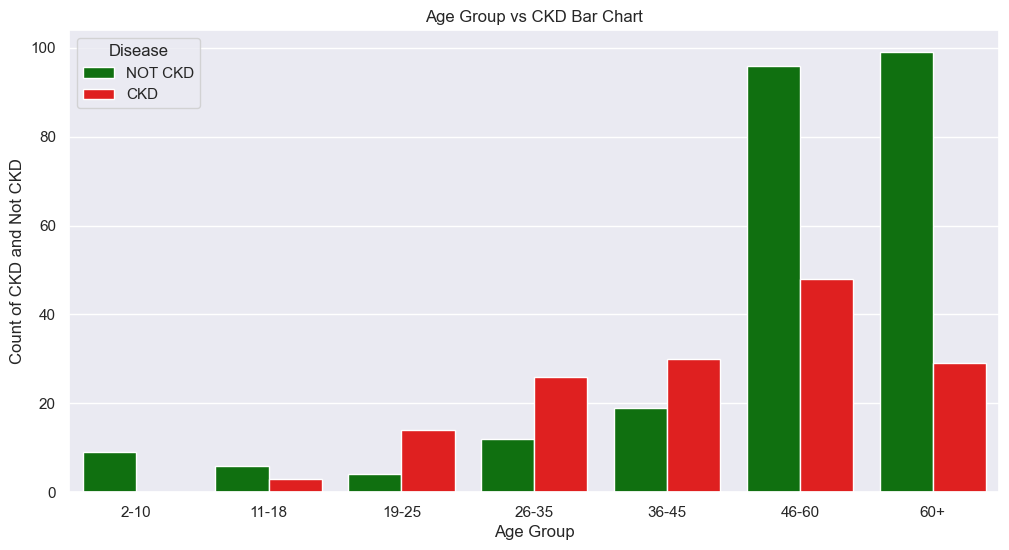

In [88]:
## Custom age bins
bins= [2,10,18,25,35,45,60,80]
lables = ['2-10','11-18','19-25','26-35','36-45','46-60','60+']

# age groupcolumn
df_imputed['Age Group'] = pd.cut(df_imputed['age'],bins = bins, labels= lables)

plt.figure(figsize=(12,6))
sns.countplot(x = 'Age Group', hue = 'class', data = df_imputed, palette=['green','red'])
plt.xlabel('Age Group')
plt.ylabel('Count of CKD and Not CKD')
plt.title('Age Group vs CKD Bar Chart')
plt.legend(title = 'Disease',labels = ['NOT CKD','CKD'])
plt.show()

### Insights:
- People in the age group of 46-60 have high chances of Chronic Kidney Disease
- According to this data set people in age group of 19-45 have more people that have CKD than NOT CKD

## Total of CKD and NOT CKD using Plotly

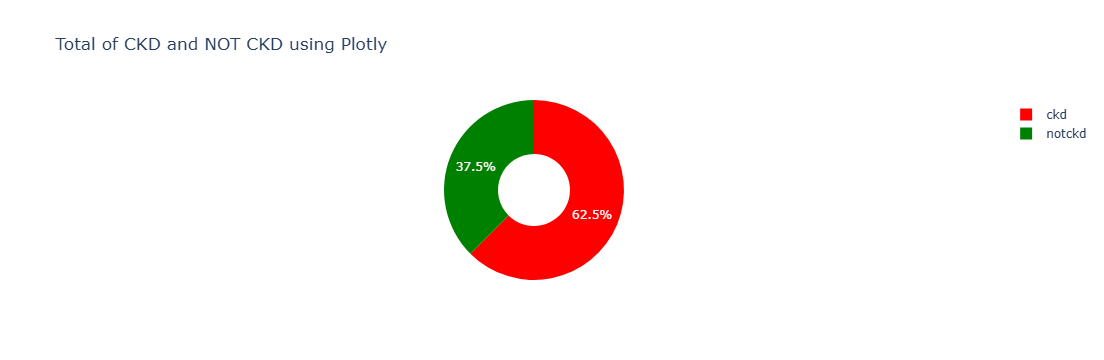

In [82]:
import plotly.express as px

# Count classes
class_counts = df_imputed['class'].value_counts().reset_index()
class_counts.columns = ['class', 'count']

custom_colors = ['red', 'green']  

fig = px.pie(
    class_counts,
    names='class',
    values='count',
    title='Total of CKD and NOT CKD using Plotly',
    hole=0.4,
    color_discrete_sequence=custom_colors
)

fig.show()


In [83]:
df_imputed.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class,Age Group
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,7800.0,5.2,yes,yes,no,good,no,no,ckd,46-60
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,99.0,...,6000.0,5.2,no,no,no,good,no,no,ckd,2-10
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,7500.0,5.2,no,yes,no,poor,no,yes,ckd,60+
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,6700.0,3.9,yes,no,no,poor,yes,yes,ckd,46-60
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,7300.0,4.6,no,no,no,good,no,no,ckd,46-60


In [84]:
df_imputed.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
count,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,51.675000,76.575000,1.017712,0.90000,0.395000,142.642500,56.883000,2.992875,136.978750,4.379250,12.848000,39.260000,8775.500000,4.868750
std,17.022008,13.489785,0.005434,1.31313,1.040038,76.344226,49.345921,5.630207,9.263352,2.858281,2.841008,8.191162,2597.309144,0.871606
min,2.000000,50.000000,1.005000,0.00000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.015000,0.00000,0.000000,99.000000,27.000000,0.900000,135.000000,3.500000,10.875000,34.000000,6975.000000,4.500000
50%,55.000000,80.000000,1.020000,0.00000,0.000000,114.500000,44.000000,1.200000,136.000000,4.050000,13.500000,41.000000,9450.000000,5.200000
75%,64.000000,80.000000,1.020000,2.00000,0.000000,150.000000,61.750000,2.725000,141.000000,4.800000,15.000000,44.000000,9800.000000,5.200000
max,90.000000,180.000000,1.025000,5.00000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [ ]:
## Classification vs Blood Pressure

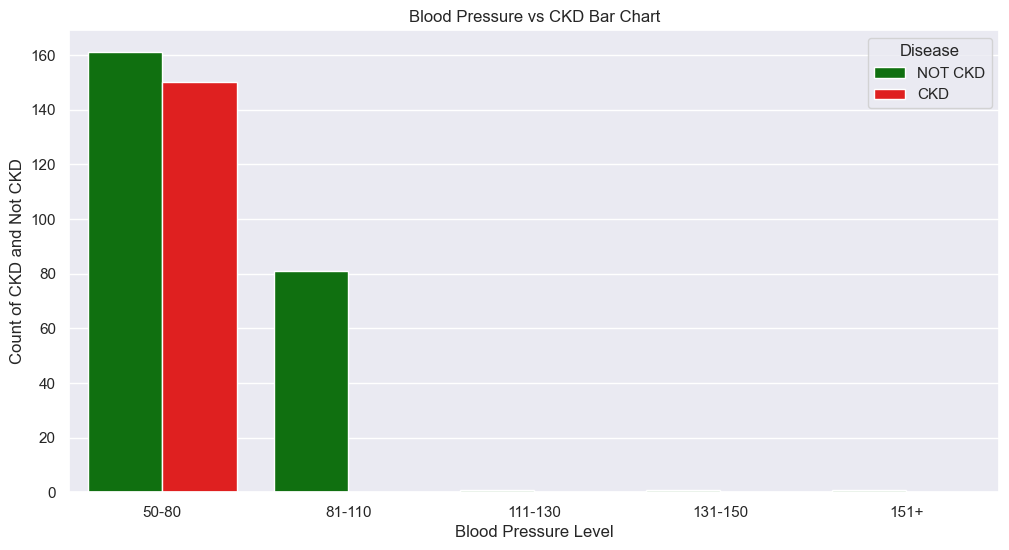

In [87]:
bins_bp = [50,80,110,130,150,180]
labels_bp = ['50-80','81-110','111-130','131-150','151+']

df_imputed['BP Custom'] = pd.cut(df_imputed['blood_pressure'],bins=bins_bp,labels = labels_bp)

plt.figure(figsize=(12,6))
sns.countplot(x = 'BP Custom', hue = 'class', palette=['green','red'], data = df_imputed)
plt.xlabel('Blood Pressure Level')
plt.ylabel('Count of CKD and Not CKD')
plt.title('Blood Pressure vs CKD Bar Chart')
plt.legend(title = 'Disease',labels = ['NOT CKD','CKD'])
plt.show()

### Insights:
- People having BP in the range of 50-80 has high chance of getting CKD
- Acc to this data people having a BP of 80+ have no CKD

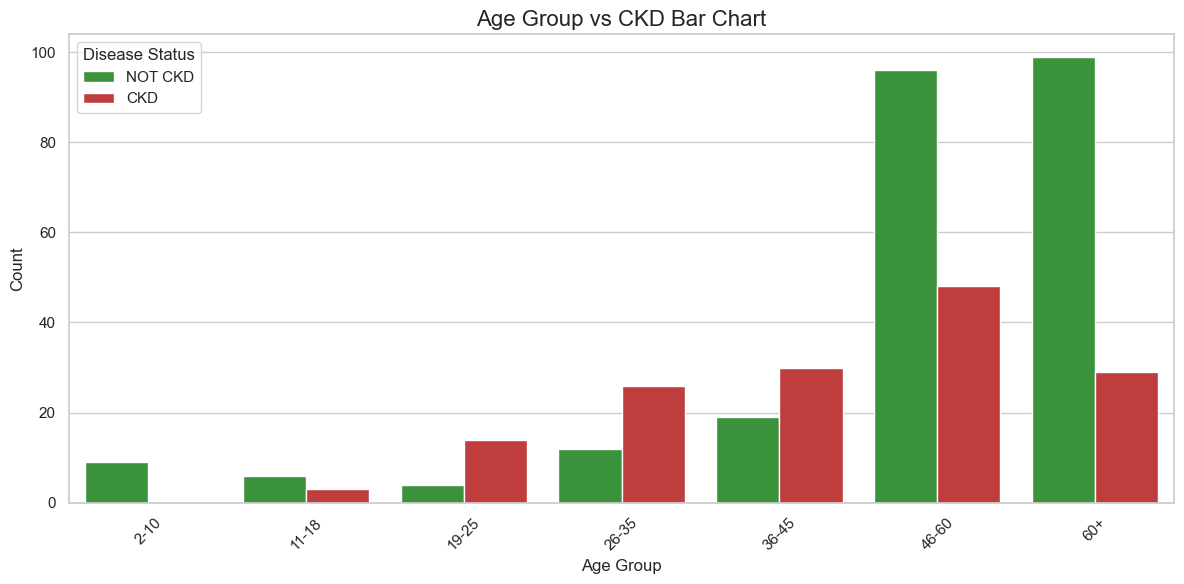

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define bins and labels
bins = [2, 10, 18, 25, 35, 45, 60, 80]
labels = ['2-10', '11-18', '19-25', '26-35', '36-45', '46-60', '60+']

# Create Age Group column
df_imputed['Age Group'] = pd.cut(df_imputed['age'], bins=bins, labels=labels)

# Set style
sns.set(style="whitegrid")

# Use a visually appealing color palette
colors = ["#2ca02c", "#d62728"]  # Green for NOT CKD, Red for CKD

plt.figure(figsize=(12, 6))
sns.countplot(x='Age Group', hue='class', data=df_imputed, palette=colors)

# Labels and title
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Age Group vs CKD Bar Chart', fontsize=16)
plt.legend(title='Disease Status', labels=['NOT CKD', 'CKD'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Pie Chart for Patients having Hypertension, Diabetes and coronary_artery_disease


In [95]:
features_pie = ['diabetes_mellitus','hypertension','coronary_artery_disease']

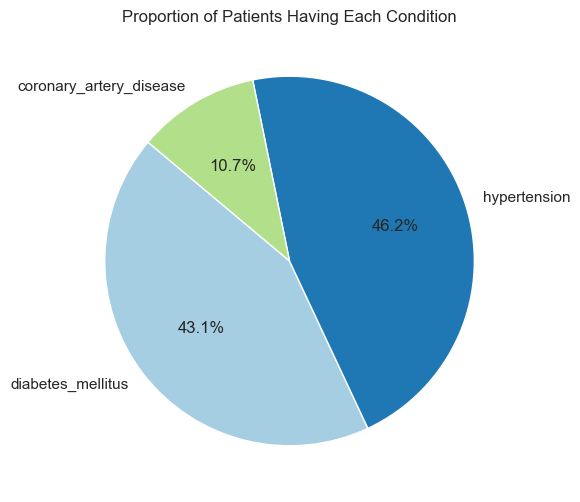

In [97]:
# Create a dictionary to store counts
yes_counts = {}

# Count only 'yes' values for each feature
for i in features_pie:
    yes_count = df_imputed[i].str.lower().value_counts().get('yes', 0)   # .lower() handles 'Yes' vs 'yes' and 0 if no 'yes' was found
    yes_counts[i] = yes_count

# Now plot a pie chart showing distribution of 'yes' counts across different conditions
plt.figure(figsize=(8,6))
plt.pie(yes_counts.values(), labels=yes_counts.keys(), autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proportion of Patients Having Each Condition')
plt.
plt.show()

In [101]:
df_imputed.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class,Age Group,BP Custom
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,5.2,yes,yes,no,good,no,no,ckd,46-60,50-80
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,99.0,...,5.2,no,no,no,good,no,no,ckd,2-10,NaN
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,5.2,no,yes,no,poor,no,yes,ckd,60+,50-80
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,3.9,yes,no,no,poor,yes,yes,ckd,46-60,50-80
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,4.6,no,no,no,good,no,no,ckd,46-60,50-80


## Box Plot

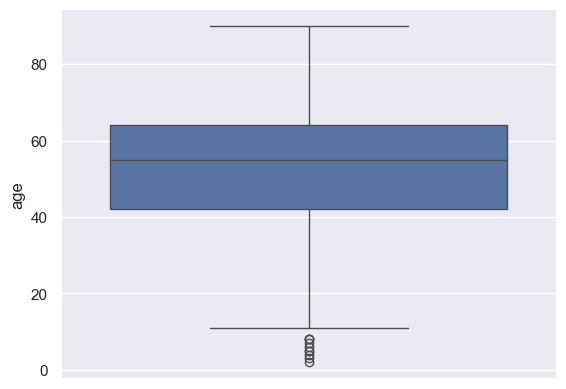

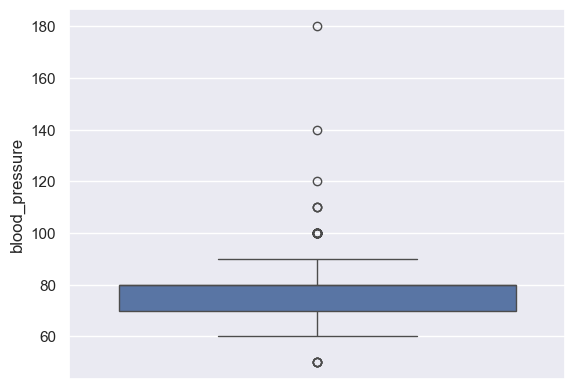

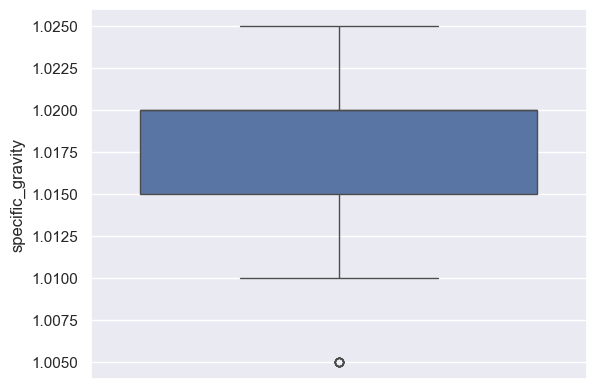

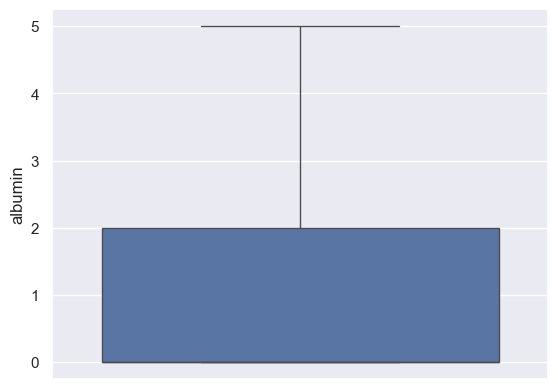

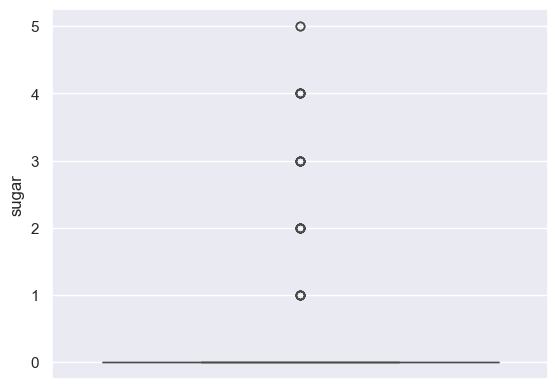

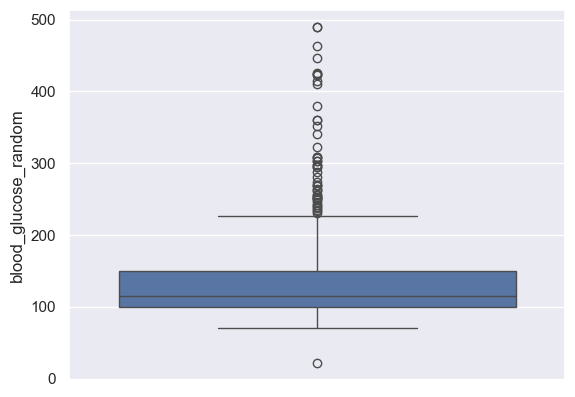

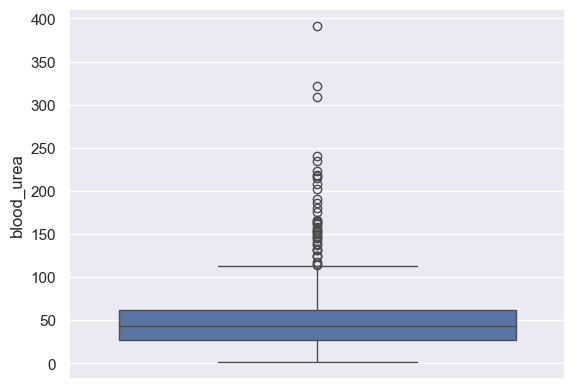

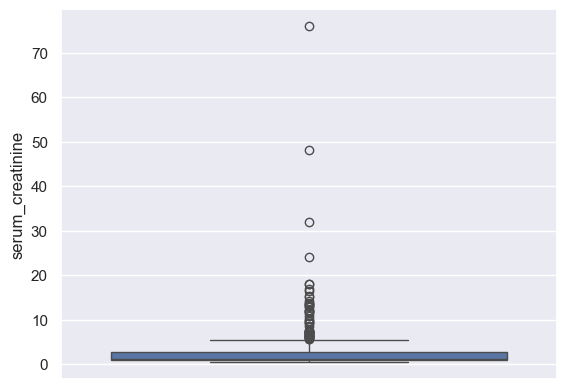

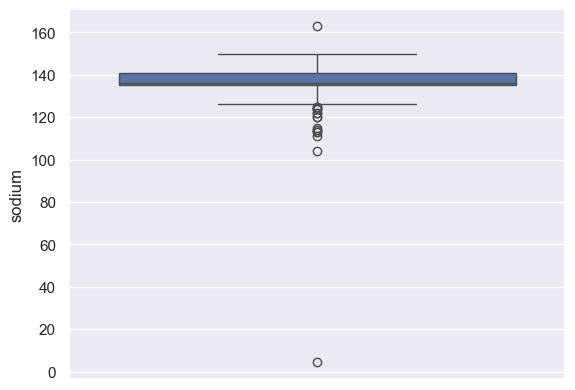

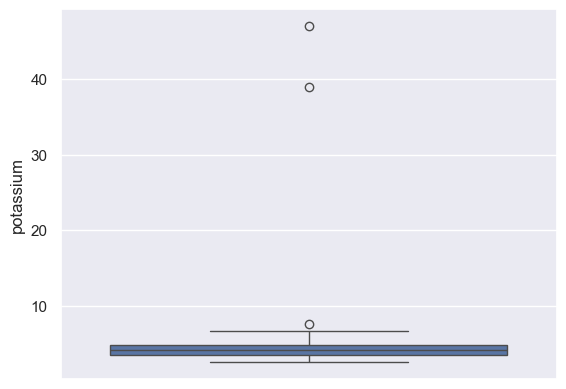

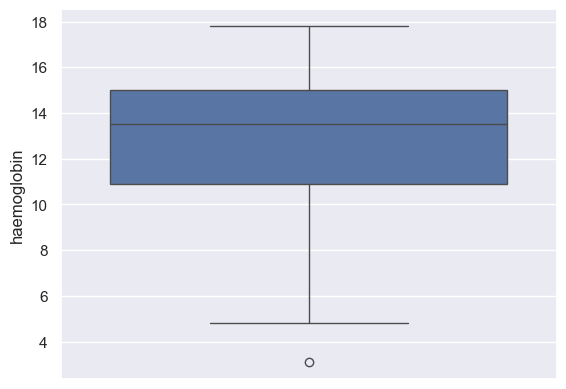

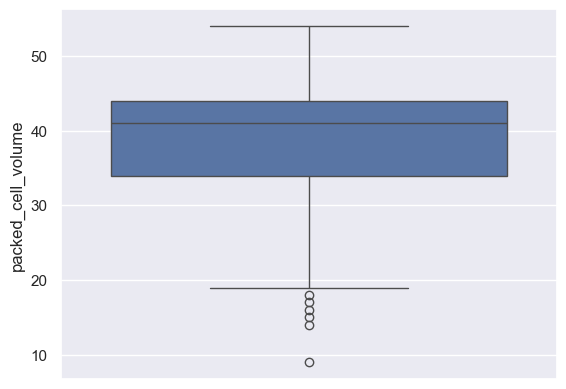

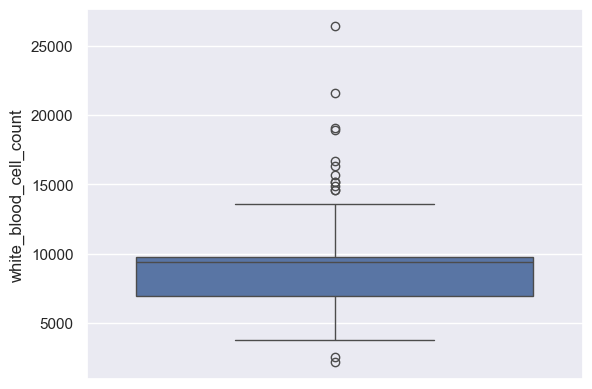

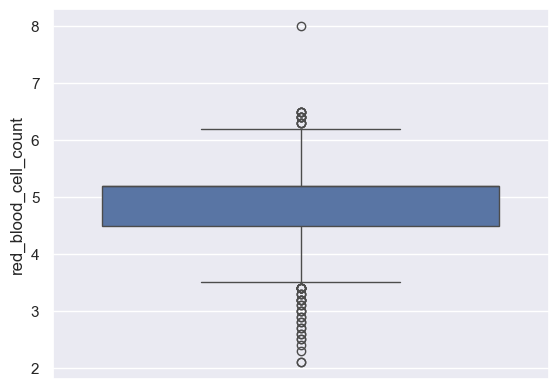

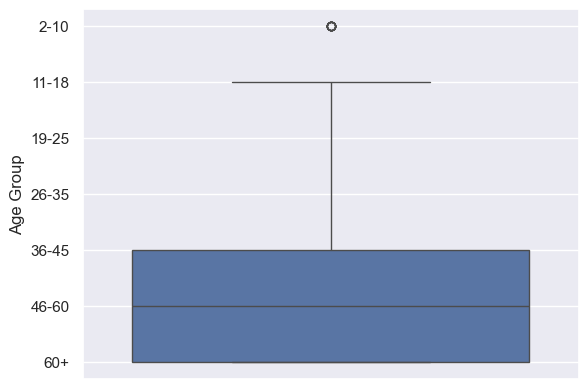

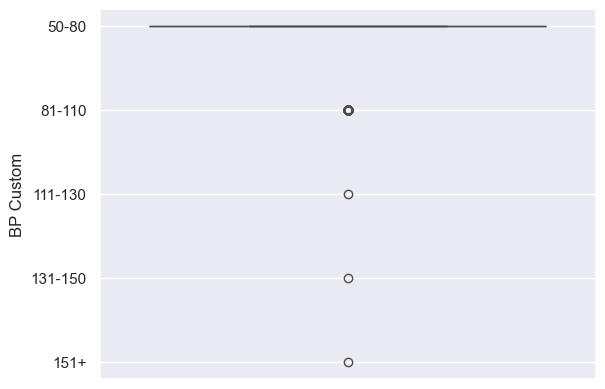

In [104]:
for i in df_imputed.select_dtypes(exclude='object'):
    sns.boxplot(df_imputed[i])
    plt.show()

In [106]:
## As we can see that there are outliers in every single feature and this is an clinical sector dataset so we will
## not treat the outliers as we don't have any domain knowledge.

## Histograms

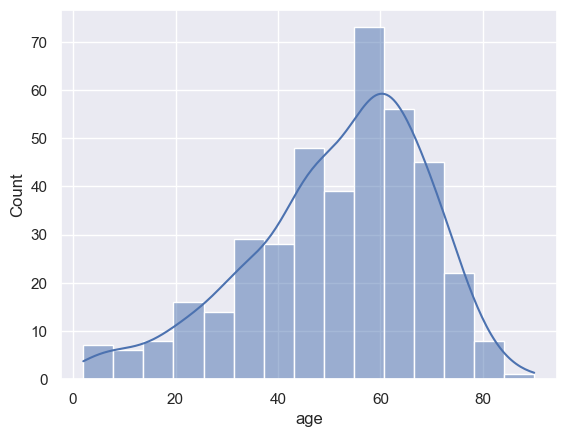

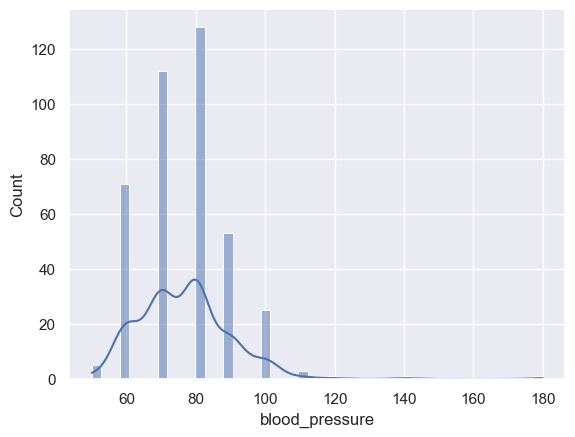

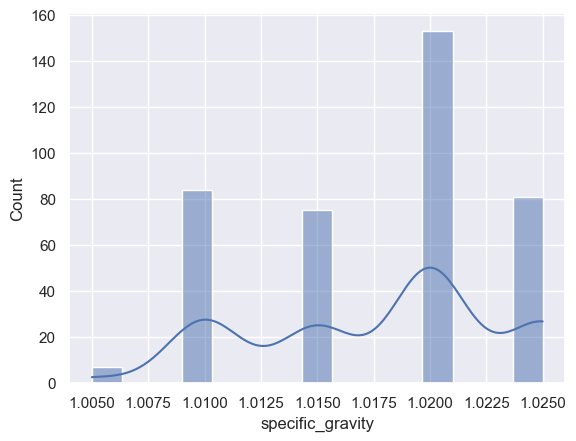

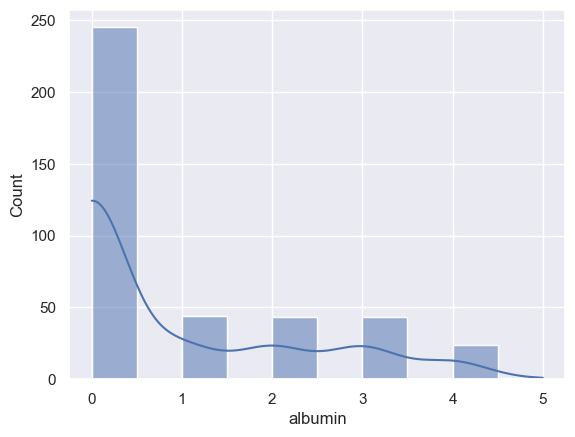

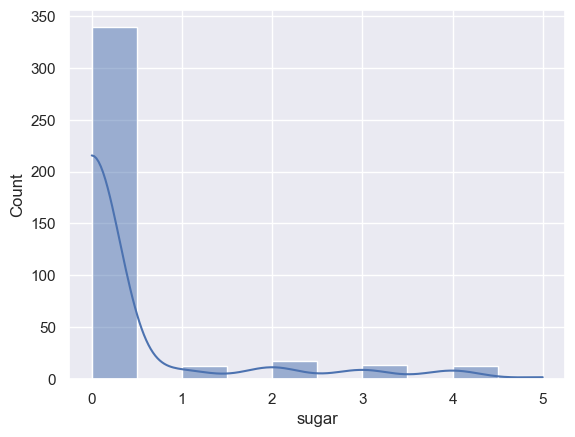

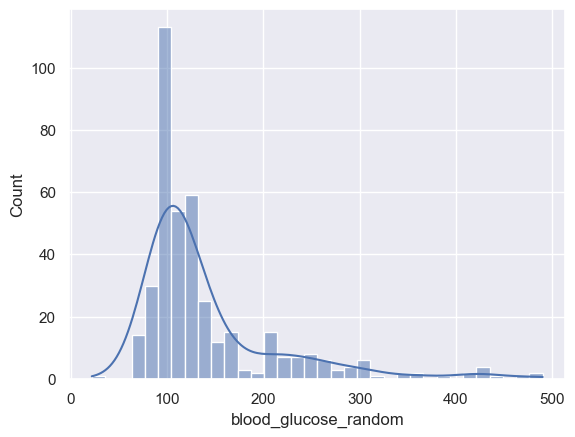

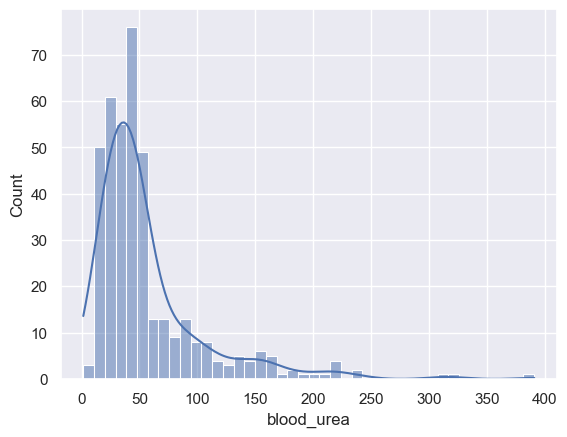

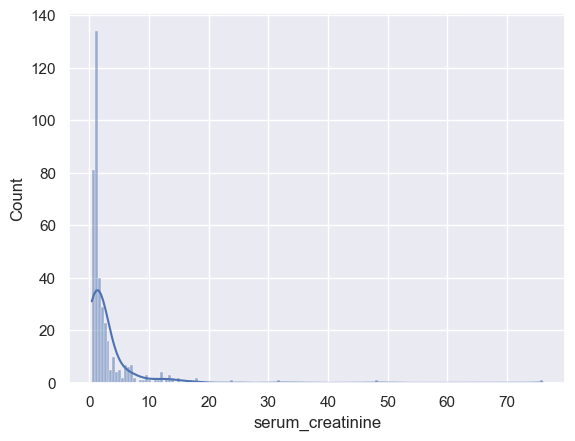

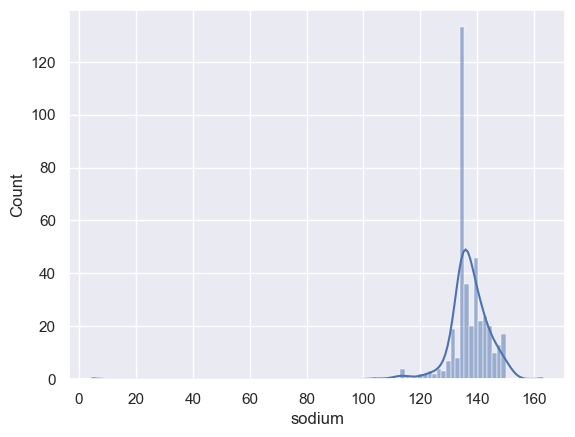

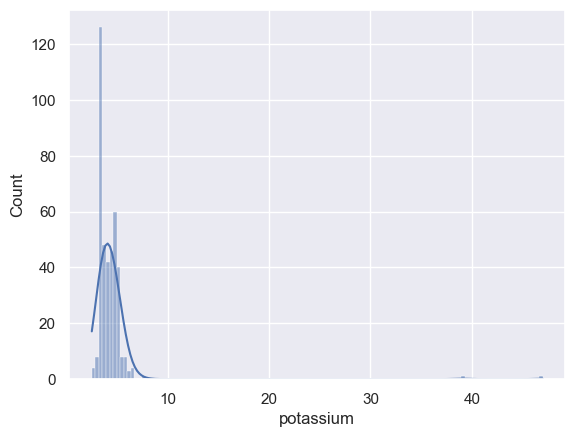

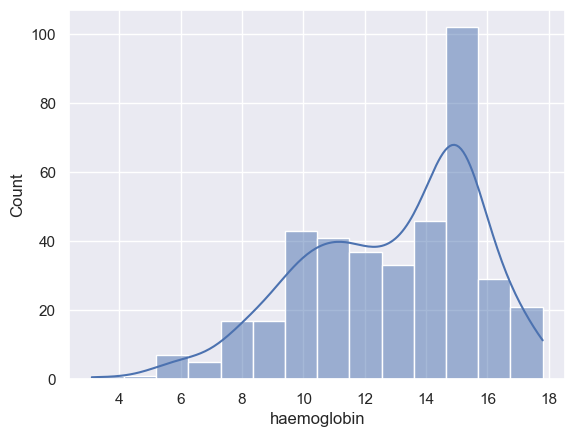

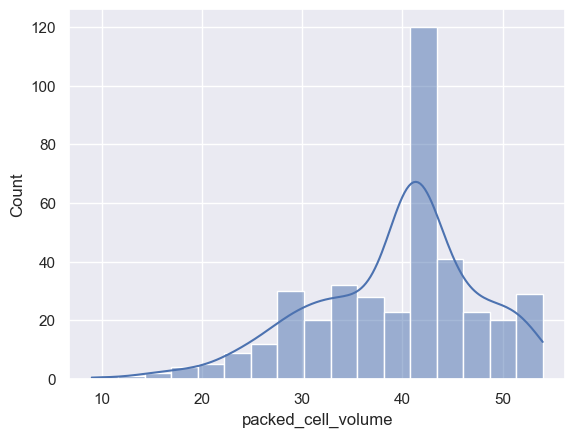

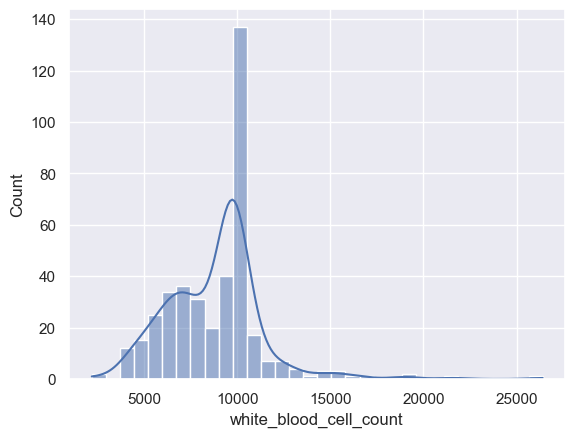

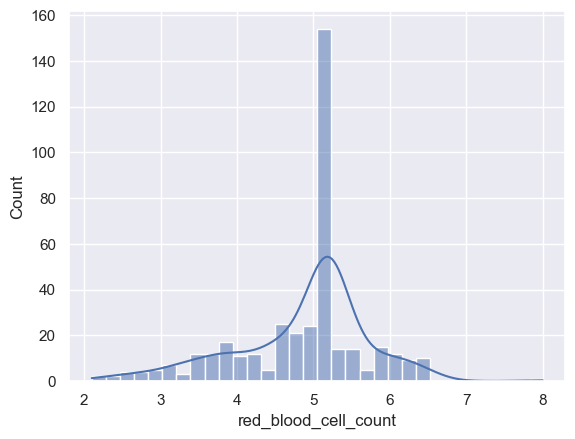

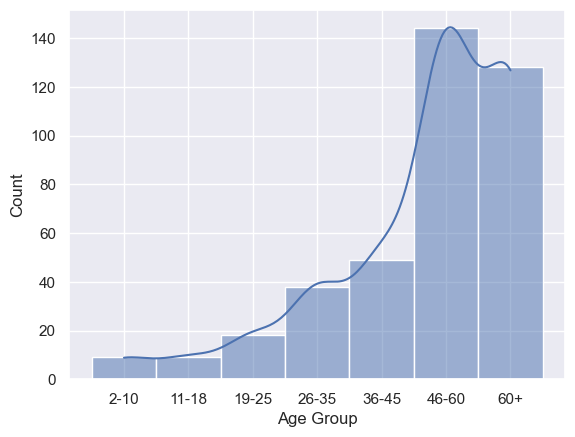

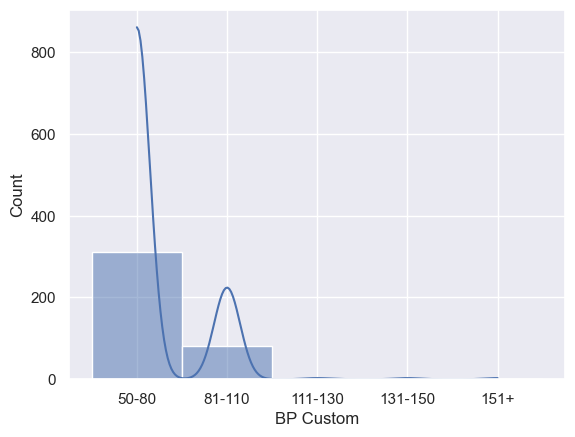

In [108]:
for i in df_imputed.select_dtypes(exclude='object'):
    sns.histplot(df_imputed[i],kde=True)
    plt.show()

In [111]:
# As we are doing a classification model we don't need to fix skewness because models like Random Forest and XGBoost are 
# tree-based models, and they are not sensitive to skewness in your data.

## Encoding
- we will do Label Encoding here

In [113]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   age                      400 non-null    float64 
 1   blood_pressure           400 non-null    float64 
 2   specific_gravity         400 non-null    float64 
 3   albumin                  400 non-null    float64 
 4   sugar                    400 non-null    float64 
 5   red_blood_cells          400 non-null    object  
 6   pus_cell                 400 non-null    object  
 7   pus_cell_clumps          400 non-null    object  
 8   bacteria                 400 non-null    object  
 9   blood_glucose_random     400 non-null    float64 
 10  blood_urea               400 non-null    float64 
 11  serum_creatinine         400 non-null    float64 
 12  sodium                   400 non-null    float64 
 13  potassium                400 non-null    float64 
 14  haemoglobi

In [114]:
df_imputed["class"]= df_imputed["class"].astype("category")
df_imputed["class"]= df_imputed["class"].cat.codes

In [116]:
df_imputed["red_blood_cells"]= df_imputed["red_blood_cells"].astype("category")
df_imputed["red_blood_cells"]= df_imputed["red_blood_cells"].cat.codes

In [117]:
df_imputed["pus_cell"]= df_imputed["pus_cell"].astype("category")
df_imputed["pus_cell"]= df_imputed["pus_cell"].cat.codes

In [118]:
df_imputed["pus_cell_clumps"]= df_imputed["pus_cell_clumps"].astype("category")
df_imputed["pus_cell_clumps"]= df_imputed["pus_cell_clumps"].cat.codes

In [119]:
df_imputed["bacteria"]= df_imputed["bacteria"].astype("category")
df_imputed["bacteria"]= df_imputed["bacteria"].cat.codes

In [120]:
df_imputed["hypertension"]= df_imputed["hypertension"].astype("category")
df_imputed["hypertension"]= df_imputed["hypertension"].cat.codes

In [121]:
df_imputed["diabetes_mellitus"]= df_imputed["diabetes_mellitus"].astype("category")
df_imputed["diabetes_mellitus"]= df_imputed["diabetes_mellitus"].cat.codes

In [122]:
df_imputed["coronary_artery_disease"]= df_imputed["coronary_artery_disease"].astype("category")
df_imputed["coronary_artery_disease"]= df_imputed["coronary_artery_disease"].cat.codes

In [123]:
df_imputed["appetite"]= df_imputed["appetite"].astype("category")
df_imputed["appetite"]= df_imputed["appetite"].cat.codes

In [124]:
df_imputed["peda_edema"]= df_imputed["peda_edema"].astype("category")
df_imputed["peda_edema"]= df_imputed["peda_edema"].cat.codes

In [125]:
df_imputed["aanemia"]= df_imputed["aanemia"].astype("category")
df_imputed["aanemia"]= df_imputed["aanemia"].cat.codes

In [126]:
df_imputed["aanemia"]= df_imputed["aanemia"].astype("category")
df_imputed["aanemia"]= df_imputed["aanemia"].cat.codes

In [128]:
df_imputed.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class,Age Group,BP Custom
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,5.2,1,1,0,0,0,0,0,46-60,50-80
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,99.0,...,5.2,0,0,0,0,0,0,0,2-10,NaN
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,5.2,0,1,0,1,0,1,0,60+,50-80
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,3.9,1,0,0,1,1,1,0,46-60,50-80
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,4.6,0,0,0,0,0,0,0,46-60,50-80


In [129]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   age                      400 non-null    float64 
 1   blood_pressure           400 non-null    float64 
 2   specific_gravity         400 non-null    float64 
 3   albumin                  400 non-null    float64 
 4   sugar                    400 non-null    float64 
 5   red_blood_cells          400 non-null    int8    
 6   pus_cell                 400 non-null    int8    
 7   pus_cell_clumps          400 non-null    int8    
 8   bacteria                 400 non-null    int8    
 9   blood_glucose_random     400 non-null    float64 
 10  blood_urea               400 non-null    float64 
 11  serum_creatinine         400 non-null    float64 
 12  sodium                   400 non-null    float64 
 13  potassium                400 non-null    float64 
 14  haemoglobi

## Heat Map

In [131]:
df_new = df_imputed.drop(columns=['Age Group','BP Custom'])

In [132]:
corr = df_new.corr()

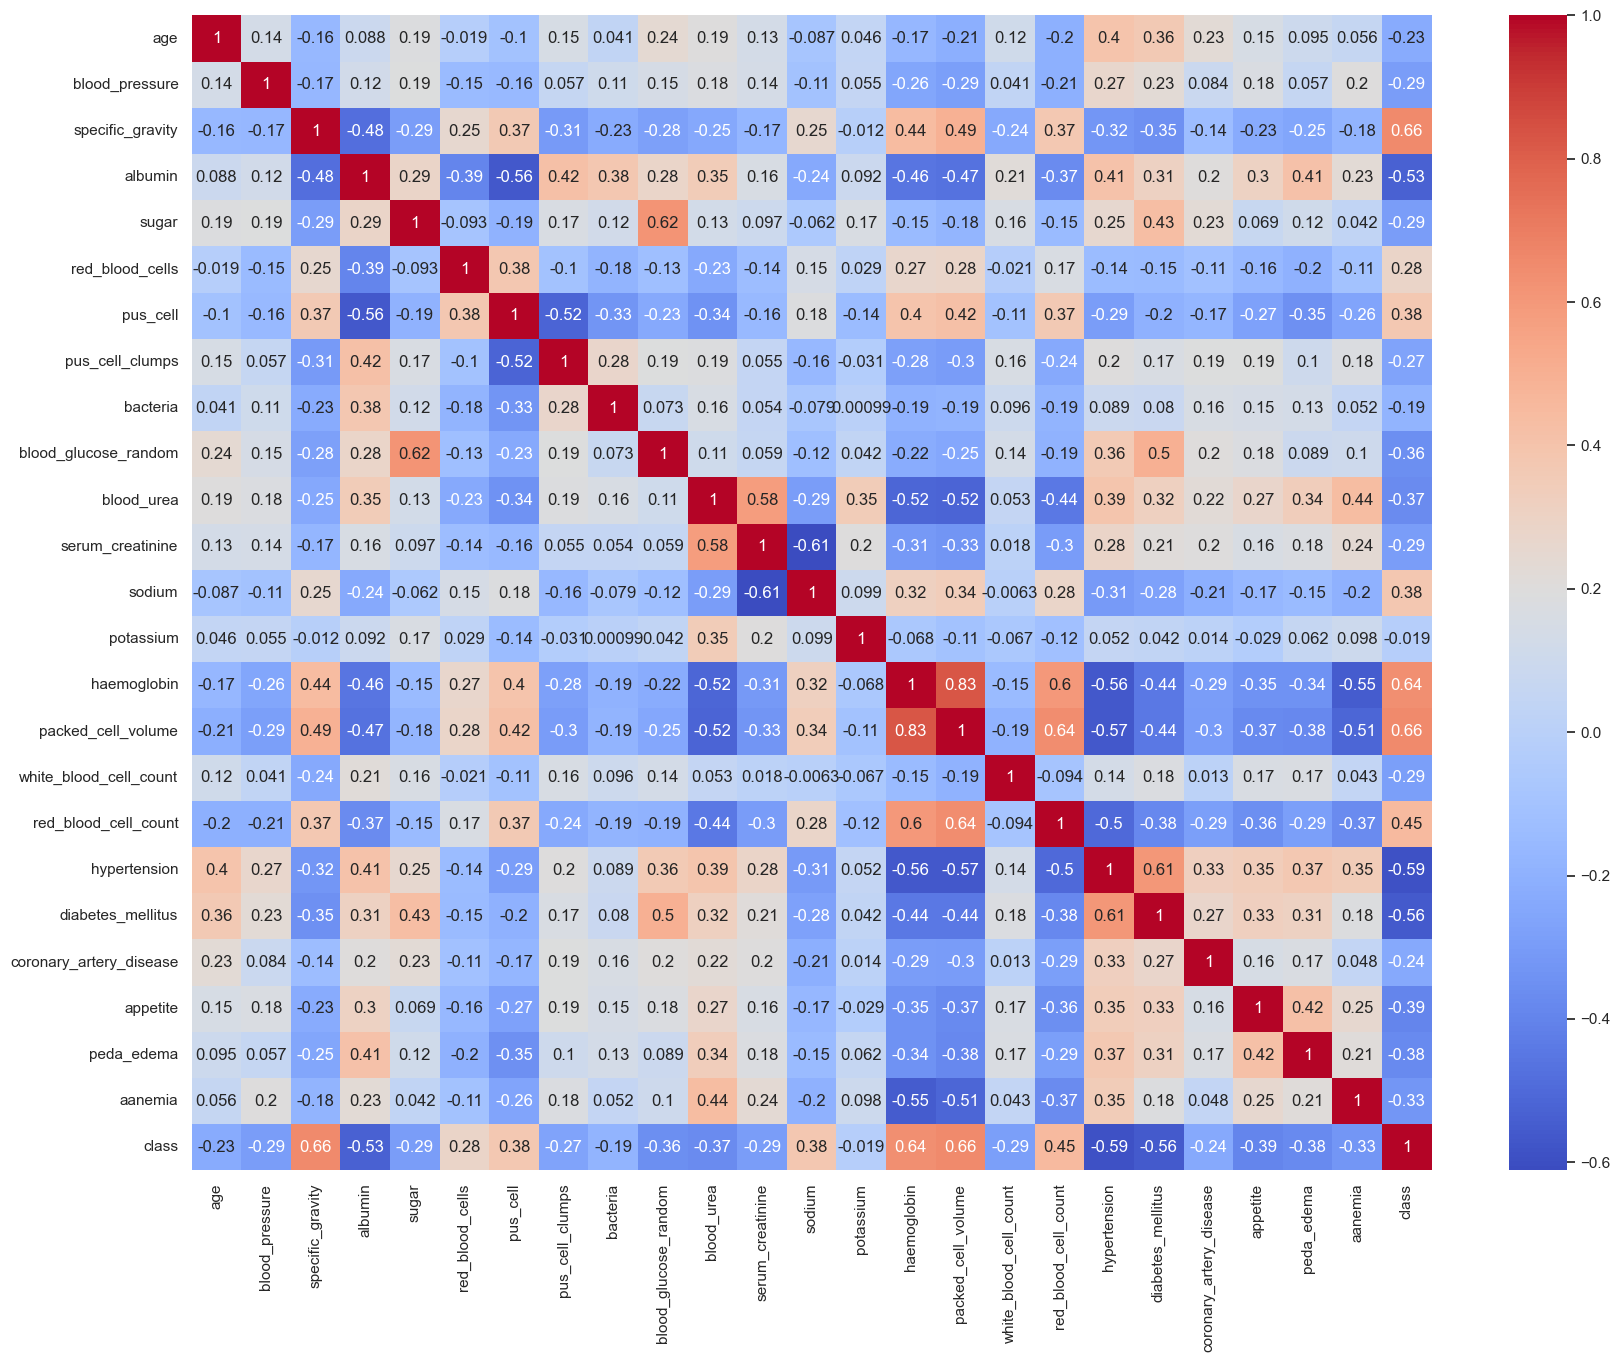

In [135]:
plt.figure(figsize=(20,15))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

## Model Building

In [136]:
# split the dataset in independent and dependent variable
x = df_new.drop(columns='class')

In [137]:
y = df_new["class"]

In [138]:
# lets detect and label balance
import imblearn
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
x_ros, y_ros = ros.fit_resample(x,y)
print("original data :", y.value_counts())
print()
print("Balanced data :", y_ros.value_counts())

original data : class
0    250
1    150
Name: count, dtype: int64

Balanced data : class
0    250
1    250
Name: count, dtype: int64


## Feature Engineering Method - PCA (Prinicipal Component Analysis)
    - We use this we don't need all of the features as some features doesn't help in determining the outcome
    - So we use PCA

In [139]:
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls
from sklearn.decomposition import PCA

pca = PCA(.95)
x_pca = pca.fit_transform(x)
print("Before PCA",x.shape)
print()
print("After PCA", x_pca.shape)

Before PCA (400, 24)

After PCA (400, 1)


In [140]:
# Split the data into Training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_pca,y,test_size=0.2,random_state=42,stratify=y)

## Building classification Model/Algo

In [173]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from xgboost import XGBClassifier

In [142]:
# Buliding an fucntion for all Models
def eval_model(model):
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test,y_pred)
    class_report = classification_report(y_test,y_pred)
    conf = confusion_matrix(y_test,y_pred)
    return {"Accuracy:":acc,"Classification Report:":class_report,"Confusion Matrix:":conf}

results = {}

In [143]:
# Models
log_reg = LogisticRegression(max_iter = 1000,random_state=42)
results["Logistic Regression"] = eval_model(log_reg)

#decison tree
dt = DecisionTreeClassifier()
results["Decision Tree"] = eval_model(dt)

#Random Forest
rf = RandomForestClassifier()
results["Random Forest"] = eval_model(rf)

#Bagging
bc = BaggingClassifier()
results["Bagging"] = eval_model(bc)

#Gradient Boostong
gb = GradientBoostingClassifier()
results["Gradient Boosting"] = eval_model(gb)

#SVM
svm = SVC()
results["SVM"] = eval_model(svm)

#KNN
knn = KNeighborsClassifier()
results["KNN"] = eval_model(knn)

#Gaussian NB
gnb = GaussianNB()
results["Gaussian Naive Bayes"] = eval_model(gnb)

#Bernoulli NB
bnb = BernoulliNB()
results["Bernoulli NB"] = eval_model(bnb)

#XG Boosting
xbg = XGBClassifier()
results["XG Boosting"] = eval_model(xbg)

# Votting Classifier - Combing all models to form one strong model
evc = VotingClassifier(estimators=[("lr",log_reg),("dt",dt),("rf",rf),("bc",bc),("gb",gb),
                                   ("svm",svm),("knn",knn),("gnb",gnb),("bnb",bnb),("XGB",xbg)],
                       voting="hard",flatten_transform=True)
results["Voting Classifier"]= eval_model(evc)


In [144]:
results_df = pd.DataFrame(results).T

In [145]:
results_df["Accuracy:"]

Logistic Regression     0.5875
Decision Tree           0.6375
Random Forest           0.6375
Bagging                    0.6
Gradient Boosting        0.625
SVM                     0.6125
KNN                      0.575
Gaussian Naive Bayes    0.6125
Bernoulli NB            0.6125
XG Boosting              0.625
Voting Classifier       0.6375
Name: Accuracy:, dtype: object

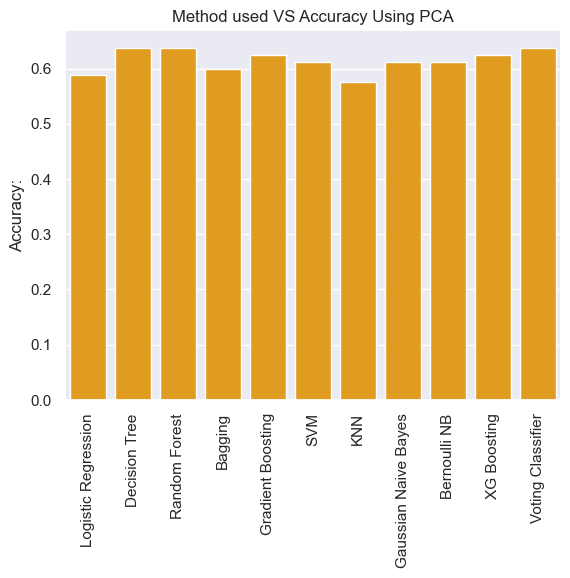

In [146]:
sns.barplot(data= results_df["Accuracy:"],color = "orange")
plt.title("Method used VS Accuracy Using PCA")
plt.xticks(rotation = 90)
plt.show()
%matplotlib inline


In [183]:
## We will not use PCA in this

## Model Building without PCA

In [148]:
# Split the data into Training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [149]:
# Buliding an fucntion for all Models
def eval_model_1(model):
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test,y_pred)
    class_report = classification_report(y_test,y_pred)
    conf = confusion_matrix(y_test,y_pred)
    return {"Accuracy:":acc,"Classification Report:":class_report,"Confusion Matrix:":conf}

results1 = {}

In [150]:
# Models
log_reg = LogisticRegression(max_iter = 1000,random_state=42)
results1["Logistic Regression"] = eval_model(log_reg)

#decison tree
dt = DecisionTreeClassifier()
results1["Decision Tree"] = eval_model(dt)

#Random Forest
rf = RandomForestClassifier()
results1["Random Forest"] = eval_model(rf)

#Bagging
bc = BaggingClassifier()
results1["Bagging"] = eval_model(bc)

#Gradient Boostong
gb = GradientBoostingClassifier()
results1["Gradient Boosting"] = eval_model(gb)

#SVM
svm = SVC()
results1["SVM"] = eval_model(svm)

#KNN
knn = KNeighborsClassifier()
results1["KNN"] = eval_model(knn)

#Gaussian NB
gnb = GaussianNB()
results1["Gaussian Naive Bayes"] = eval_model(gnb)

#Bernoulli NB
bnb = BernoulliNB()
results1["Bernoulli NB"] = eval_model(bnb)

#XG Boosting
xbg = XGBClassifier()
results1["XG Boosting"] = eval_model(xbg)

# Votting Classifier - Combing all models to form one strong model
evc = VotingClassifier(estimators=[("lr",log_reg),("dt",dt),("rf",rf),("bc",bc),("gb",gb),
                                   ("svm",svm),("knn",knn),("gnb",gnb),("bnb",bnb),("XGB",xbg)],
                       voting="hard",flatten_transform=True)
results1["Voting Classifier"]= eval_model(evc)


In [151]:
results_df1 = pd.DataFrame(results1).T

In [153]:
results_df1['Accuracy:']

Logistic Regression     0.9625
Decision Tree            0.925
Random Forest              1.0
Bagging                  0.975
Gradient Boosting          1.0
SVM                        0.6
KNN                        0.6
Gaussian Naive Bayes     0.975
Bernoulli NB            0.9625
XG Boosting                1.0
Voting Classifier          1.0
Name: Accuracy:, dtype: object

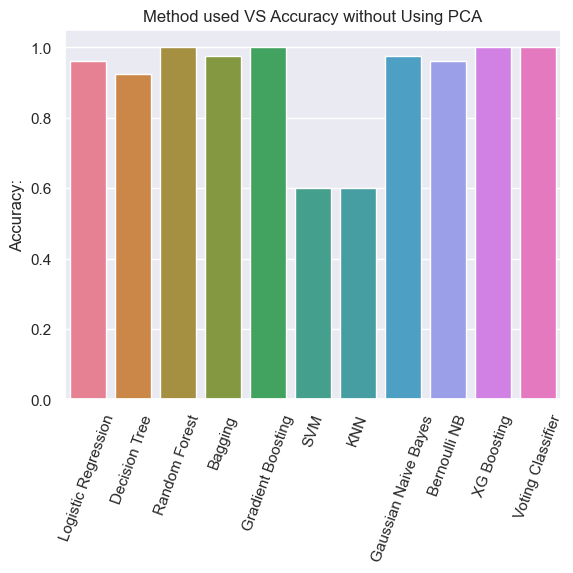

In [158]:
sns.barplot(data= results_df1["Accuracy:"],palette= "husl")
plt.title("Method used VS Accuracy without Using PCA")
plt.xticks(rotation = 70)
plt.show()
%matplotlib inline


## Cross Validation Score

In [159]:
# Cross-validation helps to evaluate the model's performance on unseen data.

from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
cv_scores1 = cross_val_score(xbg, x, y, cv=5) 

print(cv_scores1.mean())

0.9925


In [160]:
## Out XGB model performs well of unseen data as well

In [ ]:
## Cross Val for GB Model

In [168]:
# Cross-validation helps to evaluate the model's performance on unseen data.

from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
cv_scores1 = cross_val_score(gb, x, y, cv=5) 

print(cv_scores1.mean())

0.9925


In [170]:
## Our GB model also performs well of unseen data

## Now we can see that all of RF, GB and XGB got 100% accuracy but to check which model is best let's check for it's Generalisation Gap

In [ ]:
## Training acc for our XGB model

In [166]:
y_pred_train_xg = xbg.predict(x_train)

In [163]:
print(accuracy_score(y_train,y_pred_train_xg))

1.0


In [ ]:
## Training acc for our GB model

In [165]:
y_pred_train_gb = gb.predict(x_train)

In [167]:
print(accuracy_score(y_train,y_pred_train_gb))

1.0


## Here the Generalisation Gapo of Both XGB Models and GB model is none so we can go with any of the model

## Confusion Matrix

In [171]:
xgb_cf = XGBClassifier()
xgb_cf.fit(x_train,y_train)
y_pred_cf = xgb_cf.predict(x_test)

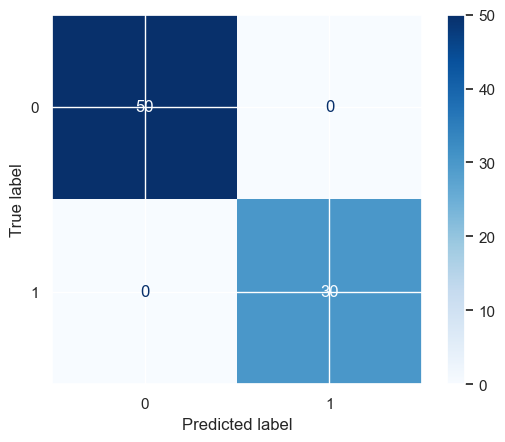

In [174]:
cm = confusion_matrix(y_test, y_pred_cf)

# Visualize it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

In [175]:
# No FP and FN values are there

## K-Fold Cross validation 

In [176]:
from sklearn.model_selection import KFold

In [181]:
X = x.to_numpy()  # Convert to NumPy array
y = y.to_numpy()  # Convert to NumPy array

kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Initialize and train your model
    xbg.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = xbg.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Calculate mean and standard deviation of accuracies
mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

print(f'Mean Accuracy: {mean_accuracy:.4f}')
print(f'Standard Deviation: {std_accuracy:.4f}')

Mean Accuracy: 0.9900
Standard Deviation: 0.0050


# Save the model for Deployment

In [184]:
ls

 Volume in drive C has no label.
 Volume Serial Number is 60DA-CDF7

 Directory of C:\Users\Harshit\Downloads\Machine Learning\Projects LearnBay\HealthCare Domain

03-03-2025  01:50    <DIR>          .
16-03-2025  08:05    <DIR>          ..
03-03-2025  01:50           305,983 16th_Feb_25_HealthCare Domain Project.ipynb
03-03-2025  01:50           405,532 22nd_16th_Feb_25_HealthCare Domain Project.ipynb
03-03-2025  01:50           150,605 Chronic+kidney+disease+(Information).pdf
03-03-2025  01:50            68,194 Chronic+Liver+Disease+-+Information.pdf
03-03-2025  01:50            25,822 HealthCare Domain Project.ipynb
03-03-2025  01:50            23,930 indian_liver_patient.csv
03-03-2025  01:50            48,551 kidney_disease.csv
03-03-2025  01:50           166,698 Parkinson_s+disease+(PD)+Information.pdf
03-03-2025  01:50            40,697 parkinsons.data
               9 File(s)      1,236,012 bytes
               2 Dir(s)  60,262,801,408 bytes free


In [185]:
import pickle
with open("XGB_Kidney_Disease.pkl","wb") as file:
    pickle.dump(xbg,file)

In [187]:
x_test.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia'],
      dtype='object')